<a href="https://colab.research.google.com/github/asleshaxa/deep-learning-generative-ai/blob/main/Denoising_Autoencoder_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Flatten, Dense, Reshape
from sklearn.metrics import mean_squared_error

In [ ]:
(X_train, _), (X_test, _) = tf.keras.datasets.mnist.load_data()

X_train = X_train[:20000].astype("float32") / 255.0
X_test = X_test[:2000].astype("float32") / 255.0

X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training shape: (20000, 28, 28, 1)
Testing shape: (2000, 28, 28, 1)


In [ ]:
noise_factor = 0.4

X_train_noisy = X_train + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=X_train.shape
)

X_test_noisy = X_test + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=X_test.shape
)

X_train_noisy = np.clip(X_train_noisy, 0, 1)
X_test_noisy = np.clip(X_test_noisy, 0, 1)

In [ ]:
input_img = Input(shape=(28, 28, 1))

x = Flatten()(input_img)
encoded = Dense(64, activation="relu")(x)

x = Dense(784, activation="sigmoid")(encoded)
decoded = Reshape((28, 28, 1))(x)

autoencoder = Model(input_img, decoded)

autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 784)            │        50,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,200 (395.31 KB)

 Trainable params: 101,200 (395.31 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = autoencoder.fit(
    X_train_noisy,
    X_train,
    epochs=5,
    batch_size=128,
    validation_data=(X_test_noisy, X_test)
)

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0757 - val_loss: 0.0516
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0439 - val_loss: 0.0380
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0341 - val_loss: 0.0303
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0275 - val_loss: 0.0263
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0243 - val_loss: 0.0239


In [ ]:
X_reconstructed = autoencoder.predict(X_test_noisy)

mse = mean_squared_error(
    X_test.reshape(-1),
    X_reconstructed.reshape(-1)
)

print("Reconstruction MSE:", mse)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Reconstruction MSE: 0.023931723088026047


In [ ]:
n = 10

plt.figure(figsize=(15, 5))

for i in range(n):
    plt.subplot(3, 10, i + 1)
    plt.imshow(X_test[i].squeeze(), cmap="gray")
    plt.axis("off")

    plt.subplot(3, 10, i + 11)
    plt.imshow(X_test_noisy[i].squeeze(), cmap="gray")
    plt.axis("off")

    plt.subplot(3, 10, i + 21)
    plt.imshow(X_reconstructed[i].squeeze(), cmap="gray")
    plt.axis("off")

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


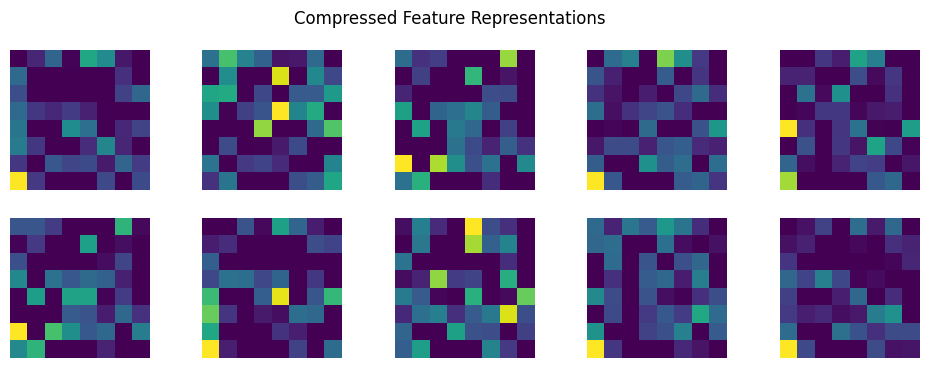

In [ ]:
encoder = Model(input_img, encoded)

compressed = encoder.predict(X_test[:10])

plt.figure(figsize=(12, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(compressed[i].reshape(8, 8), cmap="viridis")
    plt.axis("off")

plt.suptitle("Compressed Feature Representations")
plt.show()